# TOBB ETÜ Yapay Zeka Mühendisliği Bölümü
### YAP 470 / BİL 570 Dönem Projesi 3. Ara Rapor

##### İlbey Efe Taşabatlı
##### 221101026
##### YAP470

# Yüz İfadelerinin Sınıflandırılması ve Gerçek Zamanlı Tahmini

**Açıklama:**
Bu rapor, 'FANE: Facial Expressions & Emotion Dataset' (Kaggle) kullanarak yüz ifadelerini sınıflandırma projesinin
3. Ara Raporudur. Projede uygulanan detaylı Veri Keşfi ve Analizi (EDA), veri ön işleme,
SVM, Boosting ve MLP algoritmaları sunulmuştur.

EK: Şu noktada MLP ile başarılı sonuç alınamadığı için ek olarak RandomForest Metodu Eklenmiştir.

### Import Statements

In [12]:
import os
import subprocess
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

import cv2
import dlib
from skimage.feature import hog
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import xgboost as xgb



import joblib

### Deciding Optimal Input Size

In [39]:
# Gerekli fonksiyonların ve dlib detector'ünün hazırlanması
print("Gerekli araçlar ve yüz detector'ü hazırlanıyor...")
# dlib'in hazır face detection model'ını alıyoruz.
face_detector = dlib.get_frontal_face_detector()

def process_and_save_image(input_path, output_path, target_size):
    # resmi opencv ile okuma
    img = cv2.imread(str(input_path))
    if img is None: return False # resim okunamadıysa fonksiyondan çık.

    # dlib için renk uzayını BGR'den RGB'ye çeviriyoruz.
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # resimdeki yüzleri bulma işlemi.
    rects = face_detector(rgb, 1)
    if not rects: return False # face bulunamadıysa bu resmi atla.

    # bulunan ilk face'i kullanacağız.
    rect = rects[0]
    # face'in koordinatları.
    x1, y1, x2, y2 = rect.left(), rect.top(), rect.right(), rect.bottom()

    # Crop alanını biraz genişletelim, daha iyi sonuç veriyor. Yüzün etrafına %50'lik bir pay.
    w, h = x2 - x1, y2 - y1
    cx, cy = x1 + w // 2, y1 + h // 2 # Yüzün merkez noktası.
    new_w, new_h = int(w * 1.5), int(h * 1.5)
    # Yeni koordinatların resim sınırları dışına taşmasını engelle.
    nx1, ny1 = max(cx - new_w // 2, 0), max(cy - new_h // 2, 0)
    nx2, ny2 = min(cx + new_w // 2, img.shape[1]), min(cy + new_h // 2, img.shape[0])
    
    # Yüzü resimden crop'la.
    face_crop = img[ny1:ny2, nx1:nx2]
    if face_crop.size == 0: return False # eğer crop'lanan alan boşsa, bir sorun var demektir.

    # Kontrastı artırmak için CLAHE tekniği. Özellikle farklı ışık koşullarındaki face'ler için faydalı.
    img_yuv = cv2.cvtColor(face_crop, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # Sadece parlaklık (Y) kanalına CLAHE uygulanıyor.
    img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
    face_crop_clahe = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    # target_size'a getirme işlemi.
    h_crop, w_crop = face_crop_clahe.shape[:2]
    scale = target_size / max(h_crop, w_crop)
    resized = cv2.resize(face_crop_clahe, (int(w_crop * scale), int(h_crop * scale)))

    # Resmi grayscale yapıp, tam kare bir canvas'a yerleştiriyoruz.
    final_img = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    canvas = np.zeros((target_size, target_size), dtype=np.uint8) # Siyah bir canvas.
    # canvas'ın ortasına yerleştirmek için offset hesabı.
    y_off = (target_size - final_img.shape[0]) // 2
    x_off = (target_size - final_img.shape[1]) // 2
    canvas[y_off:y_off + final_img.shape[0], x_off:x_off + final_img.shape[1]] = final_img

    # Gerekli klasör yoksa oluştur ve işlenmiş image'ı kaydet.
    os.makedirs(output_path.parent, exist_ok=True)
    cv2.imwrite(str(output_path), canvas)
    return True

# Experiment parametreleri
print("Experiment için parametreler ayarlanıyor...")
TARGET_SIZES_TO_TEST = [64, 96, 128, 160] # Test edilecek image boyutları.
DATA_SUBSET_FRACTION = 0.20 # Dataset'in ne kadarlık bir kısmını kullanacağımızı belirten fraction. Hız için.
INPUT_FOLDER_NAME = "fane_data" # ham image'ların olduğu klasör.

# Ana dizin ve dataset yolları
BASE_DIR = Path().resolve()
INPUT_DATA_PATH = BASE_DIR / INPUT_FOLDER_NAME

size_experiment_results = []
image_extensions = [".jpg", ".jpeg", ".png"] # Kabul edilen image uzantıları.

# Experiment süreci
# Bütün raw image'ların yollarını bir listeye topluyoruz.
all_raw_images = [p for p in INPUT_DATA_PATH.rglob("*") if p.suffix.lower() in image_extensions]

if not all_raw_images:
    print(f"HATA: '{INPUT_DATA_PATH}' klasöründe hiç resim bulamadım. Lütfen kontrol et.")
else:
    # Farklı size'lar için ana döngü
    for target_size in TARGET_SIZES_TO_TEST:
        print(f"\n>>> Farklı bir boyutu test ediyoruz: {target_size}x{target_size} <<<")
        
        start_time_total = time.time() # bu size için süre ölçümünü başlat.
        # işlenmiş image'lar için geçici bir klasör
        temp_output_path = BASE_DIR / f'temp_processed_{target_size}'
        
        print(f"  > Adım 1: Preprocessing başlıyor...")
        # Tüm raw image'ları tek tek işleyip geçici klasöre kaydedeceğiz.
        for img_path in tqdm(all_raw_images, desc=f"İşleme ({target_size}x{target_size})", leave=False, bar_format='{l_bar}{bar:20}{r_bar}'):
            rel_path = img_path.relative_to(INPUT_DATA_PATH)
            out_path = temp_output_path / rel_path.with_suffix('.png')
            process_and_save_image(img_path, out_path, target_size)

        print(f"  > Adım 2: HOG feature extraction...")
        features_list, labels_list = [], []
        
        # İşlenmiş dosyaları label'ları (yani klasör adları) ile listele.
        processed_files_with_labels = []
        for class_dir in temp_output_path.iterdir():
            if class_dir.is_dir():
                for img_file in class_dir.glob('*.png'):
                    processed_files_with_labels.append((img_file, class_dir.name))
        
        if not processed_files_with_labels:
            print("  > Uyarı: İşlenecek dosya kalmadı, bu size atlanıyor.")
            # her experiment sonrası oluşturulan temp dosyaları temizleyelim.
            if temp_output_path.exists():
                shutil.rmtree(temp_output_path)
            continue

        # Dataset'in küçük bir subset'ini alıyoruz, experiment'ler hızlı olsun diye.
        # Stratify, subset içindeki class dağılımının orijinal dataset ile aynı olmasını sağlar.
        _, subset_files = train_test_split(
            processed_files_with_labels, 
            test_size=DATA_SUBSET_FRACTION, 
            stratify=[f[1] for f in processed_files_with_labels], 
            random_state=42
        )
        
        # subset'teki resimlerden HOG feature'larını çıkarma işlemi.
        for img_path, label in tqdm(subset_files, desc="HOG Çıkarma", leave=False, bar_format='{l_bar}{bar:20}{r_bar}'):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # HOG feature extractor
                hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                                   cells_per_block=(2, 2), visualize=False)
                features_list.append(hog_features)
                labels_list.append(label)

        X_subset, y_subset = np.array(features_list), np.array(labels_list)
        
        if X_subset.shape[0] == 0:
            print("  > Uyarı: Hiç feature çıkarılamadı. Bu size atlanıyor.")
            # her experiment sonrası oluşturulan temp dosyaları temizleyelim.
            if temp_output_path.exists():
                shutil.rmtree(temp_output_path)
            continue

        print(f"  > Adım 3: SVM model'ı için training ve testing...")
        # Training ve test için dataset'i ayır.
        X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
            X_subset, y_subset, test_size=0.25, random_state=42, stratify=y_subset
        )
        
        # Scaling ve SVM model'ını birleştiren bir pipeline. Daha pratik.
        pipe_fast_svm = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(C=1, gamma='scale', random_state=42))
        ])
        
        # Model training.
        pipe_fast_svm.fit(X_train_exp, y_train_exp)
        # Test set'iyle prediction yap.
        y_pred_exp = pipe_fast_svm.predict(X_test_exp)
        # Accuracy'i ölç.
        accuracy = accuracy_score(y_test_exp, y_pred_exp)
        
        total_duration = time.time() - start_time_total
        
        # Sonuçları listeye ekle.
        size_experiment_results.append({
            'Boyut': f"{target_size}x{target_size}",
            'Doğruluk': round(accuracy, 4),
            'Toplam Süre (s)': round(total_duration, 2),
            'HOG Vektör Boyutu': X_subset.shape[1]
        })
        print(f"  > Tamamlandı. Accuracy: {accuracy:.4f} | Süre: {total_duration:.2f}s | HOG Boyutu: {X_subset.shape[1]}")

        # her experiment sonrası oluşturulan temp dosyaları temizleyelim.
        if temp_output_path.exists():
            shutil.rmtree(temp_output_path)

# Sonuç raporu bloğu
print("\n" + "="*50)
print("      OPTIMAL SIZE EXPERIMENT SONUÇLARI")
print("="*50)

if size_experiment_results:
    # sonuçları daha okunaklı göstermek için pandas dataframe kullanılıyor.
    df_results = pd.DataFrame(size_experiment_results)
    print(df_results.to_string(index=False))
    
    # En yüksek accuracy oranına sahip satırı bulalım.
    best_row = df_results.loc[df_results['Doğruluk'].idxmax()]
    OPTIMAL_TARGET_SIZE = int(best_row['Boyut'].split('x')[0])
    
    print(f"\nKarar: En iyi performansı {OPTIMAL_TARGET_SIZE}x{OPTIMAL_TARGET_SIZE} size'ı verdi (Accuracy: {best_row['Doğruluk']:.2%}).")
    print("Projenin devamında bu size kullanılacak.")
else:
    print("Experiment'te bir sorun çıktı ya da sonuç alınamadı. Default size (96x96) ile devam edilecek.")
    OPTIMAL_TARGET_SIZE = 96

Gerekli araçlar ve yüz detector'ü hazırlanıyor...
Experiment için parametreler ayarlanıyor...

>>> Farklı bir boyutu test ediyoruz: 64x64 <<<
  > Adım 1: Preprocessing başlıyor...


  > Adım 2: HOG feature extraction...


  > Adım 3: SVM model'ı için training ve testing...
  > Tamamlandı. Accuracy: 0.3441 | Süre: 488.08s | HOG Boyutu: 1764

>>> Farklı bir boyutu test ediyoruz: 96x96 <<<
  > Adım 1: Preprocessing başlıyor...


  > Adım 2: HOG feature extraction...


  > Adım 3: SVM model'ı için training ve testing...
  > Tamamlandı. Accuracy: 0.3697 | Süre: 332.65s | HOG Boyutu: 4356

>>> Farklı bir boyutu test ediyoruz: 128x128 <<<
  > Adım 1: Preprocessing başlıyor...


  > Adım 2: HOG feature extraction...


  > Adım 3: SVM model'ı için training ve testing...
  > Tamamlandı. Accuracy: 0.3816 | Süre: 375.23s | HOG Boyutu: 8100

>>> Farklı bir boyutu test ediyoruz: 160x160 <<<
  > Adım 1: Preprocessing başlıyor...


  > Adım 2: HOG feature extraction...


  > Adım 3: SVM model'ı için training ve testing...
  > Tamamlandı. Accuracy: 0.3629 | Süre: 952.09s | HOG Boyutu: 12996

      OPTIMAL SIZE EXPERIMENT SONUÇLARI
  Boyut  Doğruluk  Toplam Süre (s)  HOG Vektör Boyutu
  64x64    0.3441           488.08               1764
  96x96    0.3697           332.65               4356
128x128    0.3816           375.23               8100
160x160    0.3629           952.09              12996

Karar: En iyi performansı 128x128 size'ı verdi (Accuracy: 38.16%).
Projenin devamında bu size kullanılacak.


### Preprocessing

In [13]:
# Projenin ana klasörü
BASE_DIR = Path().resolve()

# Gerekli dosya ve klasör path'leri tanımlanıyor.
ORIGINAL_DATASET_PATH = BASE_DIR / 'fane_data' # Raw dataset'in yolu.
PROCESSED_DATASET_PATH = BASE_DIR / 'processed_dataset_gray' # Preprocess edilmiş, grayscale dataset'in kaydedileceği yer.
PREPROCESSING_SCRIPT_PATH = BASE_DIR / 'preprocess.py' # Preprocessing script'inin konumu.
IMG_SIZE = (128, 128) # Bütün image'ların getirileceği standart boyut.


# Başlangıçta processed dataset'in olmadığını varsayıyoruz.
IS_PROCESSED_AVAILABLE = False
# Class isimlerini (yani klasör adlarını) tutacak liste.
CLASS_NAMES = []

# dataset'in varlığını kontrol edip class isimlerini alalım.
if ORIGINAL_DATASET_PATH.exists():
    # Orijinal dataset klasöründeki klasörleri bulup class isimleri olarak alıyoruz. Bunlar bizim label'larımız olacak.
    CLASS_NAMES = sorted([d for d in os.listdir(ORIGINAL_DATASET_PATH) if os.path.isdir(os.path.join(ORIGINAL_DATASET_PATH, d))])
    if CLASS_NAMES:
        print(f"Süper, {len(CLASS_NAMES)} class bulundu: {CLASS_NAMES}")
else:
    print(f"Hata: '{ORIGINAL_DATASET_PATH}' yolunda bir dataset bulunamadı. Program durdurulacak.")
    # Script'i burada durdurmak mantıklı, çünkü devam edemez.
    exit()

# Preprocessing kontrolü
print("\nAdım 1: Dataset'in önceden işlenip işlenmediğine bakalım...")

# Processed dataset klasörü var mı veya içi boş mu kontrolü.
if not PROCESSED_DATASET_PATH.exists() or not any(PROCESSED_DATASET_PATH.iterdir()):
    print(f"'{PROCESSED_DATASET_PATH}' klasörünü bulamadım, anlaşılan preprocessing yapılmamış.\nScript çalıştırılıyor...")

    # Script'in kendisi yerinde mi diye bir kontrol.
    if not Path(PREPROCESSING_SCRIPT_PATH).exists():
        print(f"Hata: Preprocessing için gereken '{PREPROCESSING_SCRIPT_PATH}' script'i bulunamadı.")
    else:
        # Şimdi harici Python script'ini çalıştıralım.
        # check=True sayesinde, script hata verirse program burada durur.
        result = subprocess.run(
            ['python', str(PREPROCESSING_SCRIPT_PATH)], 
            capture_output=True, 
            text=True, 
            check=True
        )
        print("Preprocessing başarıyla tamamlandı.")
        # script'ten gelen çıktıları ekrana yazdıralım.
        print(result.stdout)
        IS_PROCESSED_AVAILABLE = True
else:
    print("Processed dataset zaten mevcut. Bu adım atlanıyor.")
    IS_PROCESSED_AVAILABLE = True

# HOG feature extraction
print("\nAdım 2: HOG Feature'larını Çıkarıp Dataset'i Oluşturalım")

# feature vector'leri ve label'lar için boş listeler.
features_list = []
labels_list = []
# Numpy array'leri için başlangıç tanımı.
X, y = (np.array([]), np.array([]))

if IS_PROCESSED_AVAILABLE and CLASS_NAMES:
    image_extensions = ['*.png', '*.jpg', '*.jpeg'] # Desteklenen image formatları.
    
    # her bir class için bu döngü çalışacak.
    for class_name in CLASS_NAMES:
        class_path = PROCESSED_DATASET_PATH / class_name
        if class_path.is_dir():
            all_image_paths = []
            # klasördeki tüm image dosyalarını bul.
            for ext in image_extensions:
                all_image_paths.extend(class_path.glob(ext))
            
            # o class'a ait tüm image'ları tek tek geziyoruz.
            for img_path in tqdm(sorted(all_image_paths), desc=f"İşleniyor: {class_name}"):
                # image'ı grayscale olarak oku.
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                # image'ın varlığını ve beklenen boyutta olup olmadığını kontrol et.
                if img is not None and img.shape == IMG_SIZE:
                    # İşte can alıcı nokta: HOG feature vector'ünü çıkarma işlemi.
                    # HOG Parametreleri...
                    hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                                       cells_per_block=(2, 2), visualize=False, block_norm='L2-Hys')
                    # çıkarılan feature'u listeye ekle.
                    features_list.append(hog_features)
                    # Label'ı da (yani class adını) kendi listesine ekle.
                    labels_list.append(class_name)

    if features_list:
        # Tüm feature vector'lerini bir numpy matrisine dönüştür. (Feature Matrix - X)
        X = np.array(features_list)
        # label'ları da numpy dizisine. (Label Vector - y)
        y = np.array(labels_list)
        print(f"\nHarika! Feature matrix (X) oluşturuldu. Shape: {X.shape}")
        print(f"Label vector (y) de hazır. Shape: {y.shape}")
    else:
        print("\nUyarı: Hiç feature çıkarılamadı. 'processed_dataset_gray' klasörünü kontrol eder misin?")
else:
    print("Hata: Processed data bulunamadığı için feature extraction yapılamıyor.")

# Dataset'i bölme
print("\nAdım 3: Dataset'i Training ve Test Olarak Ayırma")

X_train, X_test, y_train, y_test = (np.array([]), np.array([]), np.array([]), np.array([]))

if X.size > 0:
    # Veriyi ayırma işlemi. %75 training, %25 test.
    # stratify=y önemli, böylece test ve training set'lerindeki class dağılımı benzer olur.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, shuffle=True, random_state=42, stratify=y
    )

    print(f"Training set'indeki sample sayısı: {X_train.shape[0]}")
    print(f"Test set'indeki sample sayısı: {X_test.shape[0]}")
else:
    print("Hata: Feature matrix (X) boş. Dataset'i bölemiyorum.")

print("\n--- DATA HAZIRLAMA İŞLEMİ TAMAMLANDI ---")
print("Aşağıdaki değişkenler model training için hazır:")
print("X_train, y_train, X_test, y_test")

Süper, 9 class bulundu: ['angry', 'confused', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'shy', 'surprise']

Adım 1: Dataset'in önceden işlenip işlenmediğine bakalım...
Processed dataset zaten mevcut. Bu adım atlanıyor.

Adım 2: HOG Feature'larını Çıkarıp Dataset'i Oluşturalım


İşleniyor: surprise: 100%|██████████| 1417/1417 [00:07<00:00, 177.19it/s]



Harika! Feature matrix (X) oluşturuldu. Shape: (11740, 8100)
Label vector (y) de hazır. Shape: (11740,)

Adım 3: Dataset'i Training ve Test Olarak Ayırma
Training set'indeki sample sayısı: 8805
Test set'indeki sample sayısı: 2935

--- DATA HAZIRLAMA İŞLEMİ TAMAMLANDI ---
Aşağıdaki değişkenler model training için hazır:
X_train, y_train, X_test, y_test


# Exploratory Data Analysis (EDA)

Orijinal dataset yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\fane_data
İşlenmiş dataset yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\processed_dataset_gray
Orijinal yol mevcut: True
İşlenmiş yol mevcut: True

Örneklenen sınıfın orijinal yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\fane_data\happy
Örneklenen sınıfın işlenmiş yolu: C:\Users\Asus Vivobook\Desktop\YAP470\yap470Proje\secondMethod\processed_dataset_gray\happy

3 adet örnek dosya adı seçildi: ['happy1420.jpg' 'happy1171.jpg' 'happy1258.jpg']


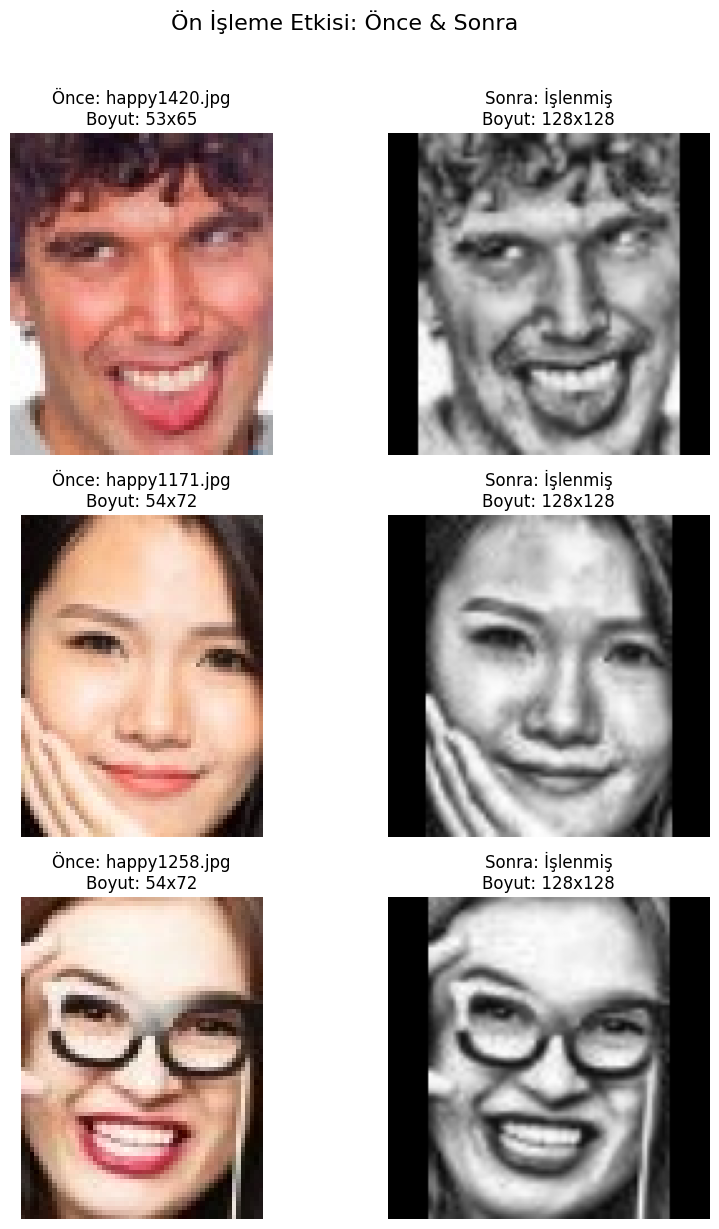


BÖLÜM B: HOG Öznitelikleri Üzerine EDA

--- B.1. Eğitim Setindeki Sınıf Dağılımı ---
Sınıf Dağılım Tablosu:
   Duygu  Sayı  Yüzde (%)
   angry   907      10.30
confused   733       8.32
 disgust   737       8.37
    fear  1455      16.52
   happy   956      10.86
 neutral  1142      12.97
     sad  1333      15.14
     shy   479       5.44
surprise  1063      12.07


C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_17348\687088995.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, order=df_counts['Duygu'], palette='viridis')


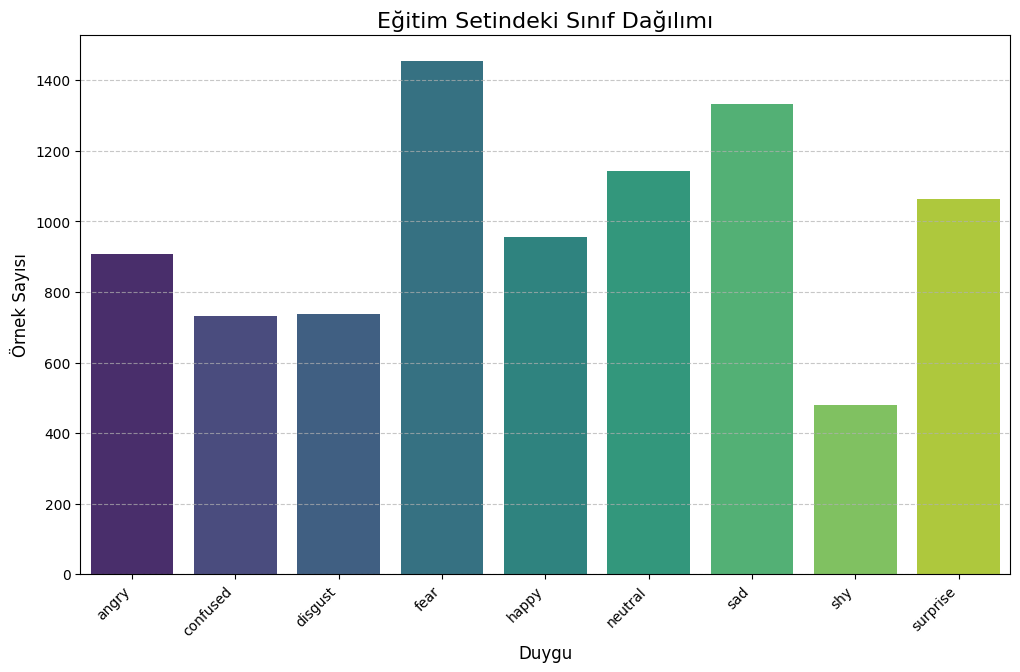


--- B.2. HOG Özniteliklerinin İstatistikleri ---
İlk 10 HOG özniteliği için istatistikler:
    count      mean       std  min       25%       50%       75%       max
0  8805.0  0.009975  0.058105  0.0  0.000000  0.000000  0.000000  0.706032
1  8805.0  0.001826  0.017719  0.0  0.000000  0.000000  0.000000  0.344827
2  8805.0  0.001001  0.012206  0.0  0.000000  0.000000  0.000000  0.325712
3  8805.0  0.001004  0.012571  0.0  0.000000  0.000000  0.000000  0.391482
4  8805.0  0.001676  0.021119  0.0  0.000000  0.000000  0.000000  0.561528
5  8805.0  0.000760  0.010493  0.0  0.000000  0.000000  0.000000  0.410589
6  8805.0  0.000751  0.008972  0.0  0.000000  0.000000  0.000000  0.292022
7  8805.0  0.001123  0.011692  0.0  0.000000  0.000000  0.000000  0.271525
8  8805.0  0.003350  0.030385  0.0  0.000000  0.000000  0.000000  0.498639
9  8805.0  0.410494  0.237221  0.0  0.350537  0.479757  0.553039  0.803613

Toplam 8100 adet HOG özniteliği bulunuyor.

--- B.3. PCA ile Sınıfların Ayrılabili

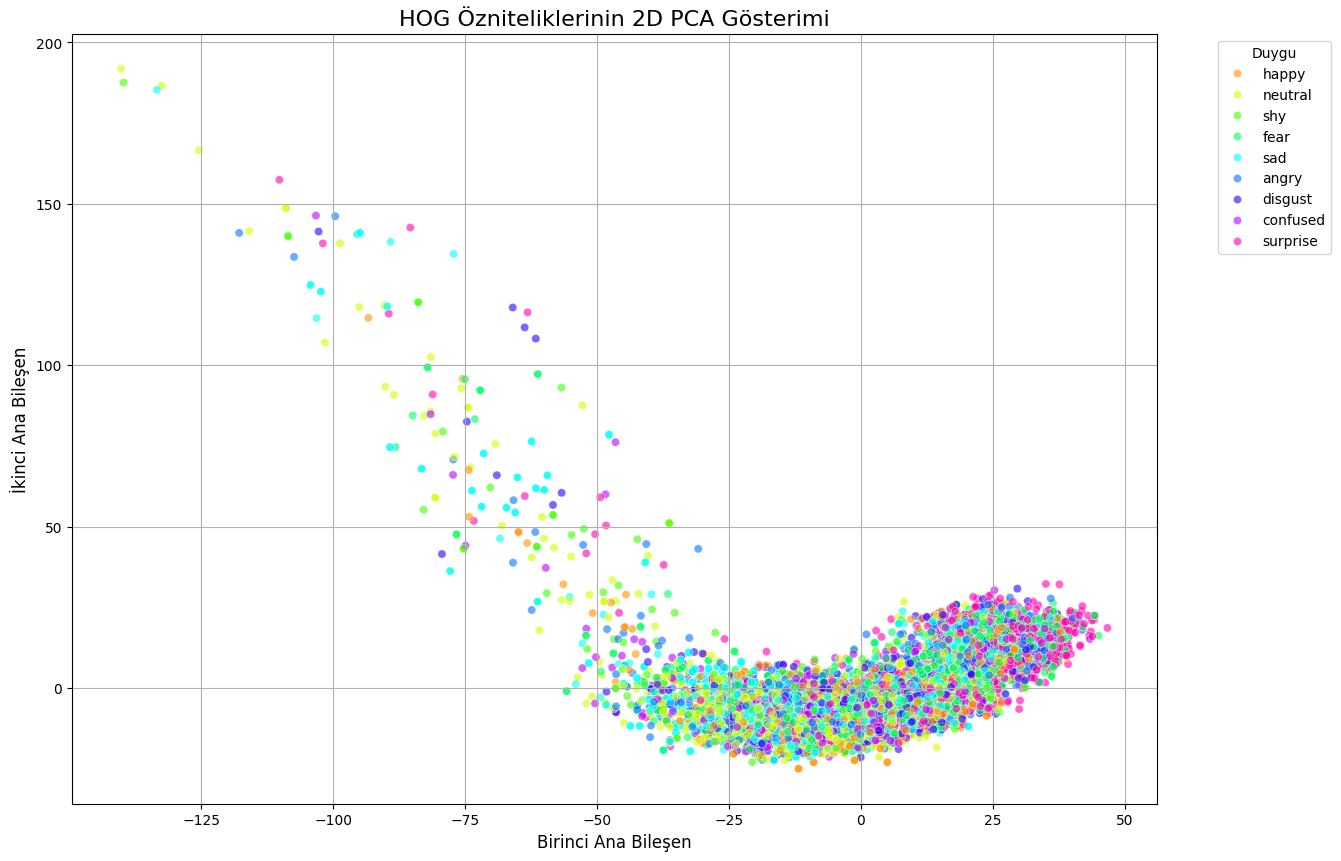


--- B.4. PCA ile Açıklanan Varyans Analizi ---
Belirli bir varyansı yakalamak için gereken PCA bileşen sayısı:
Açıklanan Varyans  Gereken Bileşen Sayısı
              80%                     693
              90%                    1161
              95%                    1582
              99%                    2590


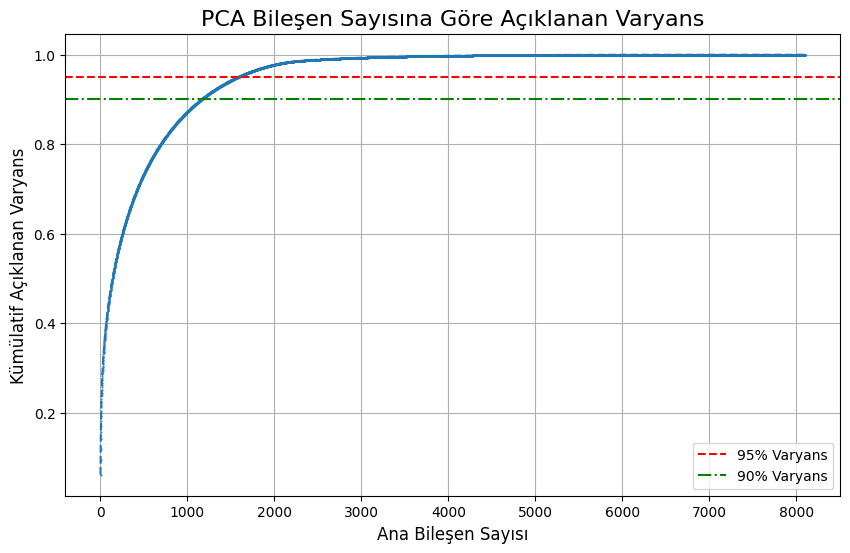


BÖLÜM C: Derinlemesine EDA

--- C.1. Sınıf Bazında Ortalama Öznitelik Değerleri ---
Her duygu için ilk 5 HOG özniteliğinin ortalama değerleri:
                 0         1         2         3         4
Duygu                                                     
angry     0.007534  0.000869  0.000125  0.000592  0.001203
confused  0.008621  0.000933  0.000658  0.000804  0.000679
disgust   0.008709  0.001693  0.000988  0.001071  0.001111
fear      0.004491  0.001029  0.000677  0.000408  0.001178
happy     0.006643  0.000911  0.000358  0.000257  0.000451
neutral   0.015246  0.003450  0.002268  0.001898  0.002743
sad       0.015898  0.003241  0.001665  0.001942  0.003193
shy       0.024939  0.003490  0.001680  0.001206  0.003085
surprise  0.004541  0.000995  0.000512  0.000702  0.001255


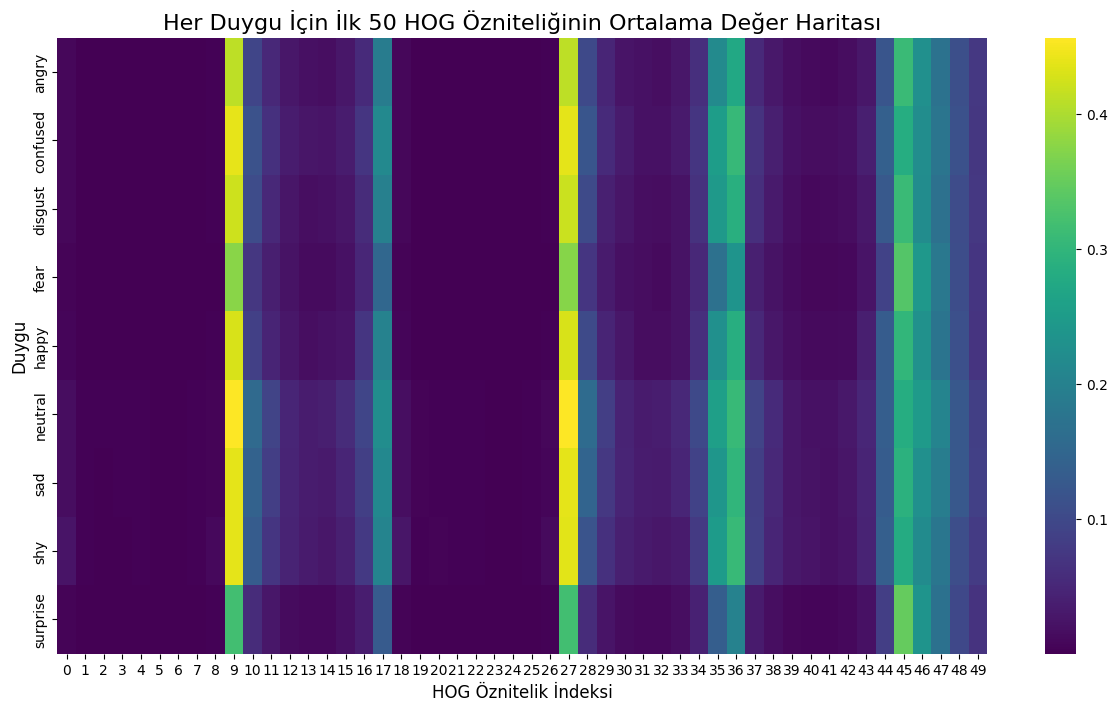


--- C.2. Örnek HOG Özniteliklerinin Dağılımı ---
Rastgele seçilen özniteliklerin istatistikleri:
              1124         5014         1963         6746
count  8805.000000  8805.000000  8805.000000  8805.000000
mean      0.143627     0.185421     0.130030     0.197445
std       0.150014     0.118565     0.101442     0.108773
min       0.000000     0.000000     0.000000     0.000000
25%       0.000000     0.076877     0.043062     0.101782
50%       0.100365     0.191322     0.109216     0.206709
75%       0.280498     0.286192     0.205081     0.291857
max       0.564323     0.528533     0.492974     0.484616


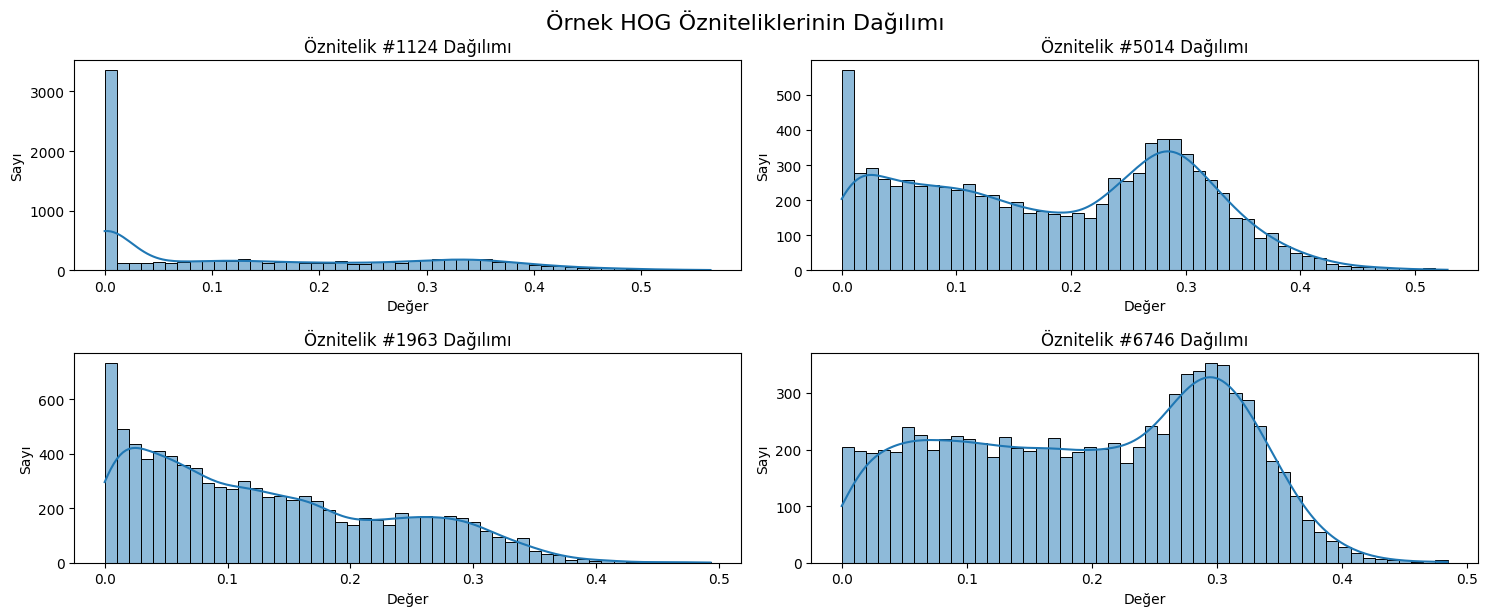


--- C.3. t-SNE ile Görselleştirme ---
t-SNE için 5000 örneklik bir alt küme kullanılıyor...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.047s...
[t-SNE] Computed neighbors for 5000 samples in 7.460s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 21.661036
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.364128
[t-SNE] KL divergence after 300 iterations: 3.094197

t-SNE sonrası veriden örnek:
   Bileşen 1  Bileşen 2     Duygu
0  -0.716103   0.067383     happy
1  -6.488715  -0.977280  confused
2  -0.583652   0.073223      fear
3  -0.736581  -0.353939     angry
4   5.230837   1.669503  surprise


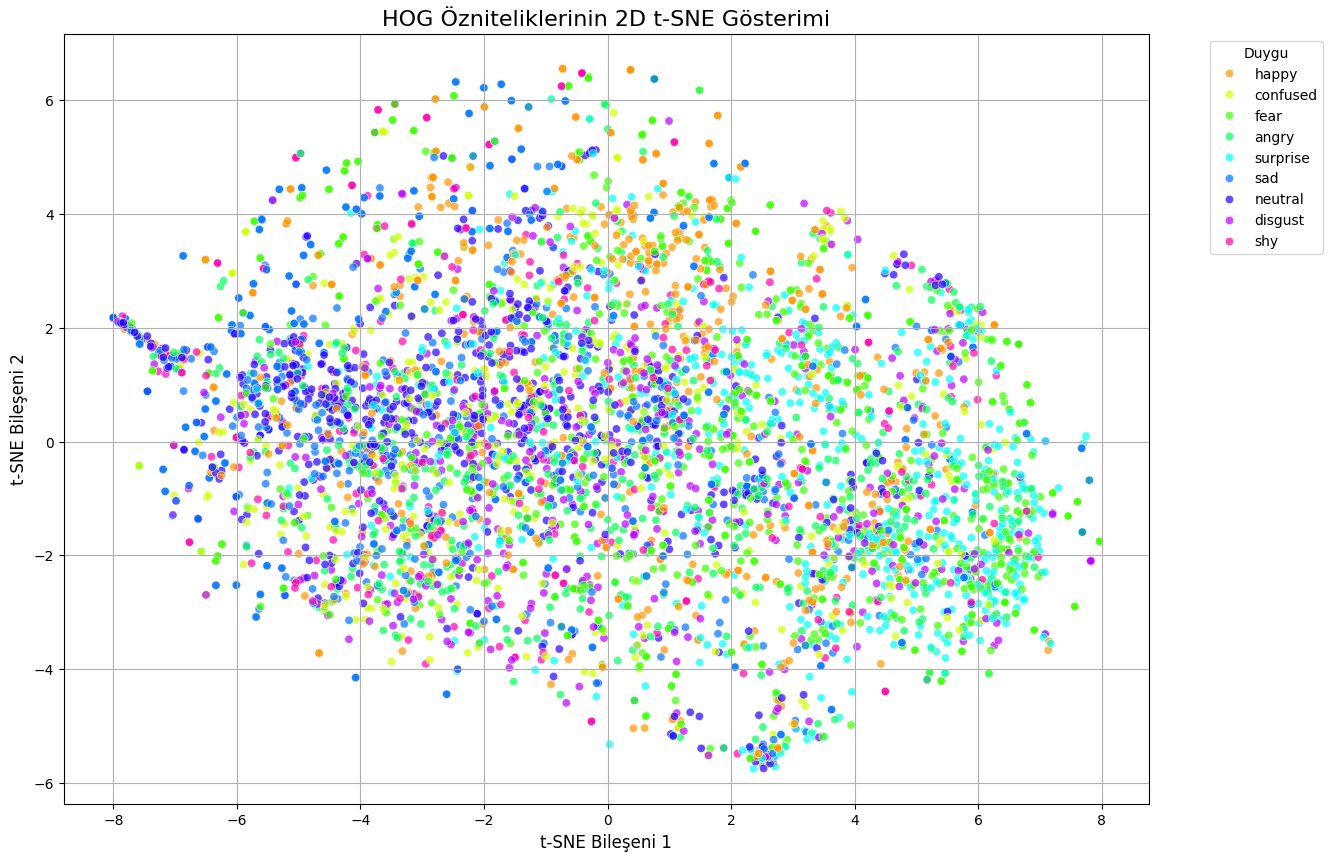


--- Tüm EDA Bölümleri Tamamlandı ---


In [ ]:
# Gerekli path'lerin kontrolü
ORIGINAL_DATASET_PATH = BASE_DIR / "fane_data"
PROCESSED_DATASET_PATH = BASE_DIR / "processed_dataset_gray"

print(f"Orijinal dataset yolu: {ORIGINAL_DATASET_PATH}")
print(f"İşlenmiş dataset yolu: {PROCESSED_DATASET_PATH}")

original_exists = ORIGINAL_DATASET_PATH.exists()
processed_exists = PROCESSED_DATASET_PATH.exists()

print(f"Orijinal yol mevcut: {original_exists}")
print(f"İşlenmiş yol mevcut: {processed_exists}")

# Ana klasörlerin varlık kontrolü
if not (original_exists and processed_exists):
    print("\nHATA: Gerekli ana dataset klasörlerinden biri veya ikisi de eksik.")
else:
    # Örnek bir class ve dosya kontrolü yapılıyor
    sample_class = 'happy'
    num_samples_to_show = 3

    original_class_path = ORIGINAL_DATASET_PATH / sample_class
    processed_class_path = PROCESSED_DATASET_PATH / sample_class
    
    print(f"\nÖrneklenen sınıfın orijinal yolu: {original_class_path}")
    print(f"Örneklenen sınıfın işlenmiş yolu: {processed_class_path}")
    
    if not original_class_path.exists() or not processed_class_path.exists():
        print(f"\nHATA: '{sample_class}' klasörü bulunamadı.")
    else:
        # Rastgele dosyaların seçimi
        original_files = [f.name for f in original_class_path.glob('*.jp*g')]
        
        if not original_files:
            print(f"\nHATA: '{original_class_path}' içinde .jpg/.jpeg dosyası bulunamadı.")
            sample_image_names = []
        else:
            # belirtilen sayıda rastgele image seçimi
            sample_image_names = np.random.choice(original_files, num_samples_to_show, replace=False)
            print(f"\n{len(sample_image_names)} adet örnek dosya adı seçildi: {sample_image_names}")

        # Görselleştirme döngüsü
        if len(sample_image_names) > 0:
            fig, axes = plt.subplots(num_samples_to_show, 2, figsize=(9, 4 * num_samples_to_show))
            if num_samples_to_show == 1: axes = np.array([axes])
            fig.suptitle('Ön İşleme Etkisi: Önce & Sonra', fontsize=16, y=1.02)

            for i, img_name in enumerate(sample_image_names):
                
                # "ÖNCE" image'ını işleme
                original_img_path = original_class_path / img_name
                original_img = cv2.imread(str(original_img_path))
                
                if original_img is not None:
                    ax = axes[i, 0]
                    ax.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
                    ax.set_title(f"Önce: {img_name}\nBoyut: {original_img.shape[1]}x{original_img.shape[0]}")
                    ax.axis('off')
                
                # "SONRA" image'ını işleme
                processed_img_path = processed_class_path / Path(img_name).with_suffix('.png')
                
                if not processed_img_path.exists():
                    # Sağ tarafı boş bırakmak yerine bir uyarı yazısı ekleyelim
                    ax = axes[i, 1]
                    ax.text(0.5, 0.5, 'İşlenmiş dosya\nbulunamadı.', horizontalalignment='center', verticalalignment='center', fontsize=10)
                    ax.set_title(f"Sonra: Bulunamadı")
                    ax.axis('off')
                else:
                    processed_img = cv2.imread(str(processed_img_path), cv2.IMREAD_GRAYSCALE)
                    if processed_img is not None:
                        ax = axes[i, 1]
                        ax.imshow(processed_img, cmap='gray')
                        ax.set_title(f"Sonra: İşlenmiş\nBoyut: {processed_img.shape[1]}x{processed_img.shape[0]}")
                        ax.axis('off')
            
            plt.tight_layout()
            plt.show()

# --- BÖLÜM B: HOG ÖZNİTELİKLERİ VE SINIF ETİKETLERİ ÜZERİNE EDA ---
print("\n" + "="*80)
print("BÖLÜM B: HOG Öznitelikleri Üzerine EDA")
print("="*80)

# --- B.1. Sınıf Dağılımı Analizi ---
print("\n--- B.1. Eğitim Setindeki Sınıf Dağılımı ---")
y_train_series = pd.Series(y_train)
class_counts = y_train_series.value_counts().sort_index()
df_counts = pd.DataFrame(class_counts).reset_index()
df_counts.columns = ['Duygu', 'Sayı']
class_percentages = y_train_series.value_counts(normalize=True).sort_index() * 100
df_counts['Yüzde (%)'] = class_percentages.values.round(2)
print("Sınıf Dağılım Tablosu:")
print(df_counts.to_string(index=False))
plt.figure(figsize=(12, 7))
sns.countplot(x=y_train, order=df_counts['Duygu'], palette='viridis')
plt.title("Eğitim Setindeki Sınıf Dağılımı", fontsize=16)
plt.ylabel('Örnek Sayısı', fontsize=12)
plt.xlabel('Duygu', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- B.2. HOG Öznitelik İstatistikleri ---
print("\n--- B.2. HOG Özniteliklerinin İstatistikleri ---")
df_features = pd.DataFrame(X_train)
feature_stats = df_features.describe().T
print("İlk 10 HOG özniteliği için istatistikler:")
print(feature_stats.head(10).to_string())
print(f"\nToplam {feature_stats.shape[0]} adet HOG özniteliği bulunuyor.")

# --- B.3. PCA ile Özniteliklerin Ayrılabilirliğini Görselleştirme ---
print("\n--- B.3. PCA ile Sınıfların Ayrılabilirliği (2 Boyutlu) ---")
scaler_eda = StandardScaler()
X_train_scaled = scaler_eda.fit_transform(X_train)
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
df_pca = pd.DataFrame(data=X_train_pca_2d, columns=['Bileşen 1', 'Bileşen 2'])
df_pca['Duygu'] = y_train
print("PCA dönüşümü sonrası veriden bir örnek:")
print(df_pca.head().to_string())
plt.figure(figsize=(14, 10))
sns.scatterplot(x='Bileşen 1', y='Bileşen 2',hue='Duygu',palette=sns.color_palette("hsv", len(CLASS_NAMES)),data=df_pca,legend="full",alpha=0.6)
plt.title('HOG Özniteliklerinin 2D PCA Gösterimi', fontsize=16)
plt.xlabel('Birinci Ana Bileşen', fontsize=12)
plt.ylabel('İkinci Ana Bileşen', fontsize=12)
plt.legend(title='Duygu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# --- B.4. Ana Bileşenlerin Açıkladığı Varyans ---
print("\n--- B.4. PCA ile Açıklanan Varyans Analizi ---")
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
variance_thresholds = [0.80, 0.90, 0.95, 0.99]
components_needed = [np.argmax(cumulative_variance >= threshold) + 1 for threshold in variance_thresholds]
df_variance = pd.DataFrame({'Açıklanan Varyans': [f"{int(v*100)}%" for v in variance_thresholds],'Gereken Bileşen Sayısı': components_needed})
print("Belirli bir varyansı yakalamak için gereken PCA bileşen sayısı:")
print(df_variance.to_string(index=False))
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--', markersize=1)
plt.title('PCA Bileşen Sayısına Göre Açıklanan Varyans', fontsize=16)
plt.xlabel('Ana Bileşen Sayısı', fontsize=12)
plt.ylabel('Kümülatif Açıklanan Varyans', fontsize=12)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varyans')
plt.axhline(y=0.90, color='g', linestyle='-.', label='90% Varyans')
plt.grid(True)
plt.legend()
plt.show()

# --- BÖLÜM C: DERİNLEMESİNE EDA ---
print("\n" + "="*80)
print("BÖLÜM C: Derinlemesine EDA")
print("="*80)

from sklearn.manifold import TSNE

# --- C.1. Sınıfa Göre Ortalama Öznitelik Değerleri ---
print("\n--- C.1. Sınıf Bazında Ortalama Öznitelik Değerleri ---")
df_features_with_labels = pd.concat([df_features, y_train_series.rename('Duygu')], axis=1)
class_feature_means = df_features_with_labels.groupby('Duygu').mean()
print("Her duygu için ilk 5 HOG özniteliğinin ortalama değerleri:")
print(class_feature_means.iloc[:, :5].to_string())
plt.figure(figsize=(15, 8))
sns.heatmap(class_feature_means.iloc[:, :50], cmap='viridis')
plt.title('Her Duygu İçin İlk 50 HOG Özniteliğinin Ortalama Değer Haritası', fontsize=16)
plt.xlabel('HOG Öznitelik İndeksi', fontsize=12)
plt.ylabel('Duygu', fontsize=12)
plt.show()

# --- C.2. Örnek HOG Özniteliklerinin Dağılımı ---
print("\n--- C.2. Örnek HOG Özniteliklerinin Dağılımı ---")
sample_feature_indices = np.random.choice(df_features.columns, 4, replace=False)
print("Rastgele seçilen özniteliklerin istatistikleri:")
print(df_features[sample_feature_indices].describe().to_string())
plt.figure(figsize=(15, 6))
for i, col_idx in enumerate(sample_feature_indices):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_features[col_idx], kde=True, bins=50)
    plt.title(f'Öznitelik #{col_idx} Dağılımı')
    plt.xlabel('Değer')
    plt.ylabel('Sayı')
plt.tight_layout()
plt.suptitle('Örnek HOG Özniteliklerinin Dağılımı', fontsize=16, y=1.02)
plt.show()

# --- C.3. t-SNE ile Gelişmiş Görselleştirme ---
print("\n--- C.3. t-SNE ile Görselleştirme ---")
n_samples_for_tsne = min(len(X_train), 5000) 
if n_samples_for_tsne < len(X_train):
    print(f"t-SNE için {n_samples_for_tsne} örneklik bir alt küme kullanılıyor...")
    _, X_subset, _, y_subset = train_test_split(
        X_train_scaled, y_train, train_size=None, test_size=n_samples_for_tsne,
        stratify=y_train, random_state=42
    )
else:
    print("t-SNE için tüm eğitim seti kullanılıyor...")
    X_subset = X_train_scaled
    y_subset = y_train

tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300, random_state=42)
X_tsne_2d = tsne.fit_transform(X_subset)

df_tsne = pd.DataFrame(data=X_tsne_2d, columns=['Bileşen 1', 'Bileşen 2'])
df_tsne['Duygu'] = y_subset
print("\nt-SNE sonrası veriden örnek:")
print(df_tsne.head().to_string())

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='Bileşen 1', y='Bileşen 2',
    hue='Duygu',
    palette=sns.color_palette("hsv", len(CLASS_NAMES)),
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('HOG Özniteliklerinin 2D t-SNE Gösterimi', fontsize=16)
plt.xlabel('t-SNE Bileşeni 1', fontsize=12)
plt.ylabel('t-SNE Bileşeni 2', fontsize=12)
plt.legend(title='Duygu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

print("\n--- Tüm EDA Bölümleri Tamamlandı ---")

### StandartScaler ve PCA



In [3]:
print("\n" + "="*80)
print("Model Training Öncesi Son Hazırlıklar StandardScaler ve PCA")
print("="*80)

# --- 1. StandardScaler ile Feature Scaling ---
# Feature'ların farklı ölçeklerde olması, bazı modellerin performansını olumsuz etkiler.
# StandardScaler, tüm feature'ları ortalaması 0, standart sapması 1 olacak şekilde dönüştürür.
# Bu işlem, modelin tüm feature'lara eşit önem vermesine yardımcı olur.

# Scaler'ı SADECE training set üzerinde 'fit' ediyoruz. 
# Bu sayede model, test set'inden hiçbir bilgi sızdırmamış olur. Bu çok önemli!
print("StandardScaler'ı training data üzerinde fit ediliyor")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Şimdi, training set'te öğrendiği parametrelerle test set'ini 'transform' ediyoruz.
print("Aynı scaler ile test datası transorm ediliyor")
X_test_scaled = scaler.transform(X_test)

print("\nStandardScaler işlemi tamamlandı. ")
print(f"  > Orijinal X_train'in ilk feature ortalaması: {X_train[:, 0].mean():.4f}")
print(f"  > Scale edilmiş X_train'in ilk feature ortalaması: {X_train_scaled[:, 0].mean():.4f}")


# --- 2. PCA ile Dimensionality Reduction (Boyut İndirgeme) ---
# HOG feature'ları çok fazla boyuta sahip olabilir. Bu, 'curse of dimensionality' sorununa yol açabilir.
# PCA, veri setindeki en önemli bilgiyi (varyansı) koruyarak feature sayısını azaltır.

# PCA'e, toplam variance'ın %95'ini koruyacak kadar component seçmesini söylüyoruz.
# Bu, component sayısını elle seçmekten daha dinamik ve iyi bir yöntem.
print("\nPCA ile boyut indirgeme işlemi")
pca = PCA(n_components=0.95, random_state=42)

# PCA'i de aynı mantıkla, sadece scale edilmiş training data üzerinde 'fit' ediyoruz.
X_train_pca = pca.fit_transform(X_train_scaled)

# Test data'yı da yine bu 'fit' edilmiş PCA modeliyle dönüştürüyoruz.
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA işlemi tamamlandı. ")
print(f"  > Orijinal feature sayısı: {X_train_scaled.shape[1]}")
print(f"  > PCA sonrası yeni feature sayısı (Variance'ın %95'i): {pca.n_components_}")
print(f"  > Training data'nın yeni shape'i: {X_train_pca.shape}")
print(f"  > Test data'nın yeni shape'i: {X_test_pca.shape}")

print("\n--- Veri Hazırlığı Tamamlandı ---")
print("Artık model training'e geçebiliriz. Son değişkenler:")
print("X_train_pca, y_train, X_test_pca, y_test")


Model Training Öncesi Son Hazırlıklar StandardScaler ve PCA
StandardScaler'ı training data üzerinde fit ediliyor
Aynı scaler ile test datası transorm ediliyor

StandardScaler işlemi tamamlandı. 
  > Orijinal X_train'in ilk feature ortalaması: 0.0100
  > Scale edilmiş X_train'in ilk feature ortalaması: -0.0000

PCA ile boyut indirgeme işlemi

PCA işlemi tamamlandı. 
  > Orijinal feature sayısı: 8100
  > PCA sonrası yeni feature sayısı (Variance'ın %95'i): 1582
  > Training data'nın yeni shape'i: (8805, 1582)
  > Test data'nın yeni shape'i: (2935, 1582)

--- Veri Hazırlığı Tamamlandı ---
Artık model training'e geçebiliriz. Son değişkenler:
X_train_pca, y_train, X_test_pca, y_test


# Model Eğitimleri

### 1. SVM

In [ ]:
print("\n" + "="*80)
print("MODEL 1: SUPPORT VECTOR MACHINE (SVM) - HİPERPARAMETRE OPTİMİZASYONU")
print("="*80)


svm_model = SVC(probability=True, random_state=42)


param_grid_svm = {

    'C': [1, 10, 100, 1000],
    

    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001] 
}


search_svm = GridSearchCV(
    estimator=svm_model,          
    param_grid=param_grid_svm,    # Denenecek parametreler.
    scoring='accuracy',           
    cv=5,                         
    n_jobs=-1,                    
    verbose=2                     
)

print("\nGridSearchCV ile hiperparametre araması başlatılıyor")
print("Test edilecek parametre kombinasyonları aşağıdadır:")
#kombinasyonlar
for c_val in param_grid_svm['C']:
    for gamma_val in param_grid_svm['gamma']:
        print(f"  - C={c_val}, gamma={gamma_val}")


search_svm.fit(X_train_pca, y_train)


print("\nSVM için GridSearchCV tamamlandı!")
print("-" * 50)
print(f"Bulunan en iyi parametreler: {search_svm.best_params_}")
print(f"Bu parametrelerle elde edilen en iyi cross doğrulama skoru: {search_svm.best_score_:.4f}")
print("-" * 50)


best_svm_model = search_svm.best_estimator_


import joblib
joblib.dump(best_svm_model, 'best_svm_model.joblib')
print("-> SVM modeli 'best_svm_model.joblib' adıyla başarıyla diske kaydedildi.")


MODEL 1: SUPPORT VECTOR MACHINE (SVM) - HİPERPARAMETRE OPTİMİZASYONU

GridSearchCV ile hiperparametre araması başlatılıyor
Test edilecek parametre kombinasyonları aşağıdadır:
  - C=1, gamma=scale
  - C=1, gamma=auto
  - C=1, gamma=0.1
  - C=1, gamma=0.01
  - C=1, gamma=0.001
  - C=10, gamma=scale
  - C=10, gamma=auto
  - C=10, gamma=0.1
  - C=10, gamma=0.01
  - C=10, gamma=0.001
  - C=100, gamma=scale
  - C=100, gamma=auto
  - C=100, gamma=0.1
  - C=100, gamma=0.01
  - C=100, gamma=0.001
  - C=1000, gamma=scale
  - C=1000, gamma=auto
  - C=1000, gamma=0.1
  - C=1000, gamma=0.01
  - C=1000, gamma=0.001
Fitting 5 folds for each of 20 candidates, totalling 100 fits

SVM için GridSearchCV tamamlandı!
--------------------------------------------------
Bulunan en iyi parametreler: {'C': 10, 'gamma': 'scale'}
Bu parametrelerle elde edilen en iyi cross doğrulama skoru: 0.5493
--------------------------------------------------
-> SVM modeli 'best_svm_model.joblib' adıyla başarıyla diske kayded

### 2. MLP (AI destekli)

In [ ]:
# =============================================================================
# MLP İÇİN SON DENEME: İleri Düzey Veri Dönüşümü ve Kararlılaştırma
# =============================================================================
# Bu blok, MLP'yi çalıştırmak için son çare olarak aykırı değerlere karşı
# en dayanıklı ölçekleyicileri ve kararlı optimizer ayarlarını dener.

from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import time

def train_mlp_last_attempt():
    print("\n" + "="*80)
    print("MLP Son Deneme: İleri Düzey Veri Dönüşümü ve Kararlılaştırma")
    print("="*80)

    # İki farklı dayanıklı pipeline tanımlayalım
    # Pipeline 1: RobustScaler kullanır
    pipe_robust = Pipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=150, random_state=42)), # PCA bileşenini sabit tutalım
        ('mlp', MLPClassifier(solver='sgd', activation='tanh', max_iter=1000, 
                               early_stopping=True, n_iter_no_change=20, random_state=42))
    ])
    
    # Pipeline 2: PowerTransformer kullanır (daha agresif)
    pipe_power = Pipeline([
        ('scaler', PowerTransformer()),
        ('pca', PCA(n_components=150, random_state=42)),
        ('mlp', MLPClassifier(solver='sgd', activation='tanh', max_iter=1000, 
                               early_stopping=True, n_iter_no_change=20, random_state=42))
    ])

    # İki pipeline için ortak bir parametre ızgarası
    param_grid = {
        'mlp__hidden_layer_sizes': [(100,), (100, 50)],
        'mlp__alpha': [0.01, 0.1], # Regularizasyonu artıralım
        'mlp__learning_rate': ['invscaling'], # Kademeli azalan öğrenme oranı
        'mlp__learning_rate_init': [0.01, 0.001] # Başlangıç öğrenme oranı
    }

    # Her iki pipeline'ı da GridSearchCV ile test etmek için bir liste
    # NOT: Bu, iki ayrı GridSearchCV çalıştıracağı için uzun sürebilir.
    # İlk olarak sadece 'RobustScaler'ı test etmek daha mantıklı olabilir.
    
    # --- Sadece RobustScaler ile Deneme ---
    print("--- Deneme 1: RobustScaler ile Pipeline Testi ---")
    
    search_mlp_robust = GridSearchCV(
        estimator=pipe_robust,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        verbose=2
    )
    
    start_time = time.time()
    search_mlp_robust.fit(X_train, y_train) # Orijinal veriyi veriyoruz
    end_time = time.time()
    
    print("\nRobustScaler ile MLP denemesi tamamlandı!")
    print(f"Süre: {(end_time - start_time) / 60:.2f} dakika")
    
    if search_mlp_robust.best_score_ > 0:
        print(f"BAŞARILI! En iyi skor: {search_mlp_robust.best_score_:.4f}")
        print(f"En iyi parametreler: {search_mlp_robust.best_params_}")
        global best_mlp_model
        best_mlp_model = search_mlp_robust.best_estimator_
    else:
        print("BAŞARISIZ! RobustScaler ile de model eğitilemedi.")
        
    # Eğer RobustScaler başarısız olursa, PowerTransformer'ı deneyebiliriz.
    # Genellikle ilki işe yaramazsa ikincisi de yaramayabilir ama denemeye değer.

if __name__ == '__main__':
    try:
        if 'X_train' in locals() and X_train.size > 0:
             train_mlp_last_attempt()
        else:
            print("HATA: Eğitim verisi (X_train) bulunamadı.")
    except Exception as e:
        print(f"Beklenmedik bir hata oluştu: {e}")


MLP Son Deneme: İleri Düzey Veri Dönüşümü ve Kararlılaştırma
--- Deneme 1: RobustScaler ile Pipeline Testi ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END mlp__alpha=0.01, mlp__hidden_layer_sizes=(100,), mlp__learning_rate=invscaling, mlp__learning_rate_init=0.01; total time=   8.1s
[CV] END mlp__alpha=0.01, mlp__hidden_layer_sizes=(100,), mlp__learning_rate=invscaling, mlp__learning_rate_init=0.01; total time=   6.8s
[CV] END mlp__alpha=0.01, mlp__hidden_layer_sizes=(100,), mlp__learning_rate=invscaling, mlp__learning_rate_init=0.01; total time=   6.8s
[CV] END mlp__alpha=0.01, mlp__hidden_layer_sizes=(100,), mlp__learning_rate=invscaling, mlp__learning_rate_init=0.001; total time=   6.0s
[CV] END mlp__alpha=0.01, mlp__hidden_layer_sizes=(100,), mlp__learning_rate=invscaling, mlp__learning_rate_init=0.001; total time=   6.0s
[CV] END mlp__alpha=0.01, mlp__hidden_layer_sizes=(100,), mlp__learning_rate=invscaling, mlp__learning_rate_init=0.001; total time=   6.

### 3. Random Forest

In [11]:

print("\n" + "="*80)
print("MODEL 3: RANDOM FOREST - HYPERPARAMETER TUNING ")
print("="*80)



rf_model = RandomForestClassifier(random_state=42)


param_grid_rf = {
    # karar ağacı sayısı
    'n_estimators': [100, 200, 300],
    
    # derinlik
    'max_depth': [10, 20, None],
    
    # min_samples_leaf: Bir dalın 'leaf' (yaprak) olabilmesi için gereken minimum sample sayısı
    'min_samples_leaf': [1, 2, 4],
    
    # max_features: Her bir ağaç dalı oluşturulurken, en iyi dallanmayı bulmak için kaç feature'a bakılacağı.
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV'yi kuralım. Bu araç, bizim için tüm olası hyperparameter kombinasyonlarını
# cross-validation ile test eder ve en iyisini bulur.
search_rf = GridSearchCV(
    estimator=rf_model,             # Optimize edilecek modelimiz.
    param_grid=param_grid_rf,       
    scoring='accuracy',             
    cv=3,                           
    n_jobs=-1,                      # Bütün CPU çekereklerini kullanarak işlemi hızlandır.
    verbose=2                       # detaylı bilgi ver.
)

print("GridSearchCV ile Random Forest için hyperparameter araması başlıyor")


start_time = time.time()

search_rf.fit(X_train_pca, y_train)
end_time = time.time()
total_duration_minutes = (end_time - start_time) / 60

print("\nRandom Forest için GridSearchCV Tamamlandı!")
print("-" * 50)
print(f"Toplam training süresi: {total_duration_minutes:.2f} dakika")
print(f"En iyi hyperparameters: {search_rf.best_params_}")
print(f"Bu parametrelerle elde edilen en iyi cross-validation accuracy: {search_rf.best_score_:.4f}")
print("-" * 50)


global best_rf_model
best_rf_model = search_rf.best_estimator_
print("\nEn iyi Random Forest modeli 'best_rf_model' değişkenine kaydedildi.")

import joblib
joblib.dump(best_rf_model, 'best_rf_model.joblib')
print("-> Random Forest modeli 'best_rf_model.joblib' adıyla başarıyla diske kaydedildi.")


MODEL 3: RANDOM FOREST - HYPERPARAMETER TUNING 
GridSearchCV ile Random Forest için hyperparameter araması başlıyor
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Random Forest için GridSearchCV Tamamlandı!
--------------------------------------------------
Toplam training süresi: 14.59 dakika
En iyi hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Bu parametrelerle elde edilen en iyi cross-validation accuracy: 0.4152
--------------------------------------------------

En iyi Random Forest modeli 'best_rf_model' değişkenine kaydedildi.
-> Random Forest modeli 'best_rf_model.joblib' adıyla başarıyla diske kaydedildi.


### 4. Gradient Boosting

In [ ]:
print("\n--- XGBoost Öncesi Label Encoding")
# XGBoost gibi bazı modeller, 'happy', 'sad' gibi string (metin) label'lar yerine 0, 1, 2 gibi sayısal label'larla daha iyi ve daha hızlı çalışır. Bu yüzden bu dönüşümü yapmılmalı


le = LabelEncoder()

# Encoder'ı training set'ine 'fit' ederek hangi string'in hangi sayıya denk geleceğini öğrenmesini sağlanıyor
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Daha sonra raporlama yaparken hangi sayının hangi class'a ait olduğunu bilmek için bu sıralamayı kaydedelim.
CLASS_NAMES_ENCODED = le.classes_

# class/number check
print("Label Mapping")
for i, class_name in enumerate(CLASS_NAMES_ENCODED):
    print(f"  '{class_name}' -> {i}")

print("\nDönüşümden önce ve sonra görüntüsü")
print(f"  > Orijinal y_train örneği: {y_train[:5]}")
print(f"  > Dönüştürülmüş y_train_encoded örneği: {y_train_encoded[:5]}")



print("\n" + "="*80)
print("MODEL 4: GRADIENT BOOSTING (XGBoost) - Hiperparametre Tuning")
print("="*80)
#optimizasyon

#
# `use_label_encoder=False` ,label encodingi yapıldı
# `eval_metric` loglama için. `random_state` yine sonuçların tutarlılığı için.
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Hyperparameter tuning için denenecek parametreler listesi.
param_grid_xgb = {
    # n_estimators: Modelin ardışık olarak oluşturacağı ağaç sayısı.
    'n_estimators': [100, 200, 300],
    # max_depth: Her bir ağacın maksimum derinliği.
    'max_depth': [3, 5, 7],
    # learning_rate: Her ağacın bir öncekinin hatasını ne kadar düzelteceğini belirler.
    'learning_rate': [0.01, 0.1, 0.2]
}

# GridSearchCV'yi kurulumu
search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=3,       
    n_jobs=-1,  
    verbose=2   
)

print("\nGridSearchCV ile XGBoost için hyperparameter araması başlıyor")


start_time = time.time()
search_xgb.fit(X_train_pca, y_train_encoded)
end_time = time.time()
total_duration_minutes = (end_time - start_time) / 60


print("\nXGBoost için GridSearchCV Tamamlandı!")
print("-" * 50)
print(f"Toplam training süresi: {total_duration_minutes:.2f} dakika")
print(f"En iyi hyperparameters: {search_xgb.best_params_}")
print(f"Bu parametrelerle elde edilen en iyi cross-validation accuracy: {search_xgb.best_score_:.4f}")
print("-" * 50)


global best_xgb_model
best_xgb_model = search_xgb.best_estimator_
print("\nEn iyi XGBoost modeli 'best_xgb_model' değişkenine kaydedildi.")

joblib.dump(best_xgb_model, 'best_xgb_model.joblib')
print("-> XGBoost modeli 'best_xgb_model.joblib' adıyla başarıyla diske kaydedildi.")

print("\nTüm modellerin eğitimi ve optimizasyonu tamamlandı!")


--- XGBoost Öncesi Label Encoding
Label Mapping
  'angry' -> 0
  'confused' -> 1
  'disgust' -> 2
  'fear' -> 3
  'happy' -> 4
  'neutral' -> 5
  'sad' -> 6
  'shy' -> 7
  'surprise' -> 8

Dönüşümden önce ve sonra görüntüsü
  > Orijinal y_train örneği: ['happy' 'neutral' 'shy' 'happy' 'shy']
  > Dönüştürülmüş y_train_encoded örneği: [4 5 7 4 7]

MODEL 4: GRADIENT BOOSTING (XGBoost) - Hiperparametre Tuning

GridSearchCV ile XGBoost için hyperparameter araması başlıyor
Fitting 3 folds for each of 27 candidates, totalling 81 fits


C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [03:54:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost için GridSearchCV Tamamlandı!
--------------------------------------------------
Toplam training süresi: 217.20 dakika
En iyi hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
Bu parametrelerle elde edilen en iyi cross-validation accuracy: 0.4744
--------------------------------------------------

En iyi XGBoost modeli 'best_xgb_model' değişkenine kaydedildi.
-> XGBoost modeli 'best_xgb_model.joblib' adıyla başarıyla diske kaydedildi.

Tüm modellerin eğitimi ve optimizasyonu tamamlandı!


In [ ]:
print("Tüm eğitilmiş modeller ve veri işleme araçları diske kaydediliyor...")
print("-" * 60)

files_to_save = {
    'scaler.joblib': 'scaler',
    'pca.joblib': 'pca',
    'label_encoder.joblib': 'le',
    'best_svm_model.joblib': 'best_svm_model',
    'best_rf_model.joblib': 'best_rf_model',
    'best_xgb_model.joblib': 'best_xgb_model'
}

saved_count = 0
for filename, var_name in files_to_save.items():
    if var_name in locals():
        joblib.dump(locals()[var_name], filename)
        print(f"-> Başarılı: '{filename}' kaydedildi.")
        saved_count += 1
    else:
        print(f"-> UYARI: '{var_name}' değişkeni bulunamadı, '{filename}' kaydedilemedi.")

print(f"\n{saved_count} adet dosya başarıyla diske kaydedildi.")